In [ ]:
!pip install xlstm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.6 MB/s eta 0:00:00


In [ ]:
from omegaconf import OmegaConf
from pprint import pprint
from dacite import from_dict
from dacite import Config as DaciteConfig
import torch
from xlstm.xlstm_block_stack import xLSTMBlockStack, xLSTMBlockStackConfig


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd drive/MyDrive/ex_comparison_forecasting

Mounted at /content/drive
/content/drive/MyDrive/ex_comparison_forecasting


In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.stats import norm
import math
import sklearn.preprocessing
import pickle
from scipy import interpolate
import random
import time
# import optuna
from sklearn.metrics import mean_absolute_error
from sklearn.multioutput import MultiOutputRegressor
from scipy.stats import linregress
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import r2_score as R2

import argparse
import torch
import torch.nn as nn
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F
import pandas as pd
import torch
import torch.nn as nn
from torch.nn.utils import weight_norm


In [ ]:
!pip install openseespy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 17.7 MB/s eta 0:00:00


In [ ]:
import openseespy.opensees as ops
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import random
import pickle

In [ ]:
file_name = 're3_new_p_data_PINN_2Dex2.p'

### Run OpenSeesPy

In [ ]:
# Nsample = 1000
# # list_ground = [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20, 23, 25, 27, 29, 31, 33, 34, 35, 37, 39, 43, 45, 46, 50]
# list_ground = [1, 2, 3, 4, 5,  8, 9, 11, 13, 14, 20, 25, 27, 33, 34, 37]
# list_name=['m1', 'm2', 'm3', 'c1', 'c2', 'c3', 'k1', 'k2', 'k3', 'intensity']
# dict_type = {'m1':'normal', 'm2':'normal', 'm3':'normal', 'c1':'log', 'c2':'log', 'c3':'log', 'k1':'normal', 'k2':'normal', 'k3':'normal', 'intensity':'normal'}
# dict_cov = {'m1':0.05, 'm2':0.05, 'm3':0.05, 'c1':0.05, 'c2':0.05, 'c3':0.05, 'k1':0.05, 'k2':0.05, 'k3':0.05, 'intensity':0.1}
# dict_variable = {}

# with open('EQall.p', 'rb') as f:
#     dfEQ = pickle.load(f)

# for k in list_name:
#     if dict_type[k] == 'normal':
#         dict_variable[k] = np.random.normal(1.0, dict_cov[k], Nsample)
#     elif dict_type[k] == 'log':
#         mean = 1.0
#         std =  dict_cov[k]
#         sigmal = np.sqrt(np.log(std**2/mean**2 + 1))
#         mu = np.log(mean) - sigmal**2/2
#         dict_variable[k] = np.random.lognormal(mu, sigmal, Nsample)

# list_K0 = [630, 630, 225] # Tn=0.7
# list_C0 = [1.0, 1.0, 0.6] # zeta = 0.02
# dict_variable['k1'] = dict_variable['k1']*list_K0[0]
# dict_variable['k2'] = dict_variable['k2']*list_K0[1]
# dict_variable['k3'] = dict_variable['k3']*list_K0[2]
# dict_variable['c1'] = dict_variable['c1']*list_C0[0]
# dict_variable['c2'] = dict_variable['c2']*list_C0[1]
# dict_variable['c3'] = dict_variable['c3']*list_C0[2]

# df = pd.DataFrame.from_dict(dict_variable)

# list_a1, list_a2, list_a3 = [], [], []
# list_v1, list_v2, list_v3 = [], [], []
# list_x1, list_x2, list_x3 = [], [], []
# list_m1, list_m2, list_m3 = [], [], []
# list_EQ = []
# list_motion = []
# Nm = 3
# g = 9.81

# for iii in range(Nsample):
#     if iii % 100 ==0:
#         print(iii)

#     i_ground = list_ground[random.randint(0, len(list_ground)-1)]
#     ops.wipe()
#     ops.model('basic','-ndm',1,'-ndf',1)

#     list_m = [df['m1'][iii], df['m2'][iii], df['m3'][iii]]
#     list_K = [df['k1'][iii], df['k2'][iii], df['k3'][iii]]
#     list_C = [df['c1'][iii], df['c2'][iii], df['c3'][iii]]
#     intensity = df['intensity'][iii]

#     ops.node(1000,0); ops.fix(1000,1)
#     for i in range(Nm):
#         ops.node(i+1,0); ops.mass(i+1,list_m[i])
#         ops.uniaxialMaterial('Elastic',i+1,list_K[i],list_C[i])
#         if i==0:
#             ops.element('zeroLength',i+1,1000,i+1,'-mat',i+1,'-dir',1)
#         else:
#             ops.element('zeroLength',i+1,i,i+1,'-mat',i+1,'-dir',1)

#     # ops.timeSeries('Path',1,'-dt',0.01,'-filePath','TakY.th','-factor',0.5*g)
#     gg = dfEQ['gEQ_FEM'][i_ground]
#     if len(gg) < 3000:
#       gg = np.append(gg,[0]*(3000-len(gg)))

#     ops.timeSeries('Path',1,'-dt', dfEQ['dt (s)'][i_ground],'-filePath',f'GMfiles/{dfEQ['Ground motions'][i_ground]}','-factor',intensity*g)
#     ops.pattern('UniformExcitation',1,1,'-accel',1)

#     ops.recorder('Node','-file','displacement3.txt','-time','-node',1, 2, 3, '-dof',1,'disp')
#     ops.recorder('Node','-file','velo3.txt','-time','-node',1, 2, 3, '-dof',1,'vel')
#     ops.recorder('Node','-file','acc3.txt','-time','-node',1, 2, 3, '-dof',1,'accel')

#     ops.analysis('Transient','-noWarnings')
#     ops.analyze(3000,0.01)

#     dx = pd.read_csv('displacement3.txt', sep='\s+',header=None)
#     dv = pd.read_csv('velo3.txt', sep='\s+',header=None)
#     da = pd.read_csv('acc3.txt', sep='\s+',header=None)

#     x, v, a = {}, {}, {}
#     for i in range(Nm):
#         x[i] = dx[i+1].values
#         v[i] = dv[i+1].values
#         a[i] = da[i+1].values


#     list_a1.append(a[0])
#     list_a2.append(a[1])
#     list_a3.append(a[2])
#     list_v1.append(v[0])
#     list_v2.append(v[1])
#     list_v3.append(v[2])
#     list_x1.append(x[0])
#     list_x2.append(x[1])
#     list_x3.append(x[2])
#     list_EQ.append(i_ground)
#     list_motion.append(gg[:3000])

# df['disp_1'] = list_a1
# df['disp_2'] = list_a2
# df['disp_3'] = list_a3
# df['disp_4'] = list_v1
# df['disp_5'] = list_v2
# df['disp_6'] = list_v3
# df['disp_7'] = list_x1
# df['disp_8'] = list_x2
# df['disp_9'] = list_x3
# df['disp_ground'] = list_motion
# df['idEQ'] = list_EQ

# with open(file_name, 'wb') as f:
#     pickle.dump(df, f)


0
100
200
300
400
500
600
700
800
900


### DL model

In [ ]:
with open(file_name, 'rb') as f:
  df_new = pickle.load(f)

for i in range(len(df_new)):
  L = len(df_new['disp_2'][i])

len(df_new)

1000

In [ ]:
def getPositionEncoding(seq_len, d, n=10000):
    P = np.zeros((seq_len, d))
    for k in range(seq_len):
        for i in np.arange(int(d/2)):
            denominator = np.power(n, 2*i/d)
            P[k, 2*i] = np.sin(k/denominator)
            P[k, 2*i+1] = np.cos(k/denominator)
    return P


In [ ]:
list_output_time = []
list_static = []

for k in list(df_new):
  if (str(k)[:4] == 'disp') & (str(k)[-1] != 'd'):
    list_output_time.append(k)

  if str(k)[:4] != 'disp':
    list_static.append(k)

print(list_static)
print(list_output_time)


['m1', 'm2', 'm3', 'c1', 'c2', 'c3', 'k1', 'k2', 'k3', 'intensity', 'idEQ']
['disp_1', 'disp_2', 'disp_3', 'disp_4', 'disp_5', 'disp_6', 'disp_7', 'disp_8', 'disp_9']


In [ ]:
L_signal_input = len(df_new['disp_2'][0])
L_ground = L_signal_input

Ndim_encoding = 2
P_encoding = getPositionEncoding(seq_len=L_signal_input, d=Ndim_encoding, n=10000)
list_input_time = ['disp_ground', 'encode_0', 'encode_1']


print(list_input_time)
print(list_output_time)

['disp_ground', 'encode_0', 'encode_1']
['disp_1', 'disp_2', 'disp_3', 'disp_4', 'disp_5', 'disp_6', 'disp_7', 'disp_8', 'disp_9']


In [ ]:
for d in range(Ndim_encoding):
  df_new[f'encode_{d}'] = [P_encoding[:,d]]*len(df_new)


In [ ]:
L_all, L_out = 150, 100
sliding_step = L_out
list_time_series = list_input_time + list_output_time
L_in = L_all-L_out
N_input= len(list_input_time)
N_output= len(list_output_time)
N_static = len(list_static)
N_all = N_input+N_output+N_static
N_time_series = len(list_input_time)+len(list_output_time)+1

max_disp = [np.max(np.abs(df_new[list_output_time[-1]][idx])) for idx in range(len(df_new))]
df_new['max_disp'] = max_disp


In [ ]:
static_scaler = sklearn.preprocessing.StandardScaler().fit(df_new[list_static].values)
target = np.array([df_new[i][0] for i in list_output_time]).T
target_scaler = sklearn.preprocessing.StandardScaler().fit(target)
real = np.array([df_new[i][0] for i in list_time_series]).T
real_scaler = sklearn.preprocessing.StandardScaler().fit(real)

In [ ]:
def prepare_data_batch(x, N1, N2, j = 2):
  N0 = np.shape(x)[1]
  xxx = np.stack([x[:,i:N0 - N1+i+1:j, :] for i in range(N1)], axis=2)
  y = xxx[:,:,-N2:,-len(list_output_time):]

  return np.array(xxx), np.array(y)

In [ ]:
gc.collect(2)
gc.collect(2)

0

In [ ]:
class h_Dataset(Dataset):
    def __init__(self, data_time, data_static, data_y):
        self.data_time = data_time
        self.data_static = data_static
        self.data_y = data_y

    def __getitem__(self, index):
        seq_time = self.data_time[index]
        seq_static = self.data_static[index]
        seq_y = self.data_y[index]
        return seq_time, seq_static, seq_y

    def __len__(self):
        return len(self.data_y)


def data_provider2(data_x, data_y, batch_size=128):
    data_set = h_Dataset(data_x, data_y)
    data_loader = DataLoader( data_set, batch_size=batch_size, shuffle=True, drop_last=True)
    return data_set, data_loader



In [ ]:
class Data_aggregation(nn.Module):
    def __init__(self, dropout=0.1):
        super(Data_aggregation, self).__init__()
        self.projection = nn.Sequential(nn.Linear(N_static, L_all), nn.ReLU(), nn.Linear(L_all, L_all))
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, x_time, x_static):
        x = self.projection(x_static)
        x = self.dropout(x)
        x = x.permute(0, 2, 1)
        x = torch.cat([x_time, x], dim=2)

        return x

In [ ]:

# [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
def gen_data_AI_batch_2_model(df_new, list_idx):
  signal = [np.stack(list(df_new[k][list_idx])) for k in list_time_series ]
  signal = np.stack(signal).transpose(1,2,0)
  signal = np.pad(signal,((0,0),(L_all,0),(0,0)),constant_values=0.0)
  signal = signal.reshape(-1, N_input + N_output)
  scaled_signal = real_scaler.transform(signal)
  scaled_signal = scaled_signal.reshape(-1, L_ground+L_all, N_input + N_output)
  X_times_series, Y_label = prepare_data_batch(scaled_signal, L_all, L_out, j = sliding_step)
  X_times_series[:,:,L_in:,N_input:N_input+N_output] = 0.0

  static = np.stack(list(df_new[k][list_idx] for k in list_static)).T
  scaled_static = static_scaler.transform(static)
  X_static = scaled_static.reshape(-1,1,1,N_static)
  X_static = np.tile(X_static, [1, X_times_series.shape[1], 1, 1])
  X_times_series = X_times_series.reshape(-1, L_all, N_input+N_output)
  X_static = X_static.reshape(-1, 1, N_static)
  Y_label =  Y_label.reshape(-1, L_out, N_output)

  return X_times_series, X_static, Y_label



In [ ]:
def data_provider2(data_time, data_static, data_y, batch_size=128):
    data_set = h_Dataset(data_time, data_static, data_y)
    data_loader = DataLoader(data_set, batch_size=batch_size, shuffle=True, drop_last=True)
    return data_set, data_loader

def loader_data(df_new, idx_train, batch_size = 128):
  list_train_time, list_train_static, list_train_label = [], [], []
  list_val_time, list_val_static, list_val_label = [], [], []
  time, static, label = gen_data_AI_batch_2_model(df_new, idx_train)
  list_train_time.append(time)
  list_train_static.append(static)
  list_train_label.append(label)

  train_time = np.concatenate(list_train_time, axis=0)
  train_static = np.concatenate(list_train_static, axis=0)
  train_label = np.concatenate(list_train_label, axis=0)
  _, train_loader = data_provider2(train_time, train_static, train_label, batch_size=batch_size)

  return train_loader


In [ ]:
idx_train = np.random.choice(len(df_new), size=500, replace=False)
idx_val = np.array([i for i in range(len(df_new)) if i not in idx_train])
idx_val = idx_val[:200]

train_loader= loader_data(df_new, idx_train, batch_size = 64)
valid_loader = loader_data(df_new, idx_val, batch_size = 64)

In [ ]:
def inference_5tor(model, aggregation, df_new, list_idx, batch_size = 512):
  x_time, x_static, _ = gen_data_AI_batch_2_model(df_new, list_idx)
  x_time = x_time.reshape(len(list_idx),-1,L_all, N_input+N_output)
  x_static = x_static.reshape(len(list_idx),-1, 1, N_static)
  # initial a long output time-series with zero
  y_predict_all = np.zeros((len(x_time), L_ground+L_all, N_output))
  for j in range(int(L_ground/L_out)+1):
    x_time[:,j,:L_all, N_input:N_input+N_output] = y_predict_all[:,L_out*j:L_all+L_out*j,:]
    xt = torch.from_numpy(x_time[:,j,:,:]).float().to('cuda')
    xs = torch.from_numpy(x_static[:,j,:,:]).float().to('cuda')
    batch_x = aggregation(xt, xs)
    y_pred_all = model(batch_x).to('cuda').cpu().detach().numpy()
    y_predict_all[:,L_in+L_out*j:L_all+L_out*j,:] = y_pred_all[:,:,:]

  y_predict_all = target_scaler.inverse_transform(y_predict_all.reshape(-1, N_output))
  y_predict_all = y_predict_all.reshape(len(x_time), -1, N_output)

  return y_predict_all

In [ ]:
class model_parameters:
  def __init__(self):
    self.d_model = 128
    self.e_layers = 2
    self.dropout = 0.1

args = model_parameters()


In [ ]:
xlstm_cfg = f"""
mlstm_block:
  mlstm:
    conv1d_kernel_size: 3
    qkv_proj_blocksize: 4
    num_heads: 1
slstm_block:
  slstm:
    backend: {'cuda' if torch.cuda.is_available() else 'vanilla'}
    num_heads: 1
    conv1d_kernel_size: 3
    bias_init: powerlaw_blockdependent
  feedforward:
    proj_factor: 1.3
    act_fn: gelu
context_length: {L_all}
num_blocks: 1
embedding_dim: {N_input+N_output+1}
slstm_at: []
"""

cfg = OmegaConf.create(xlstm_cfg)
cfg = from_dict(data_class=xLSTMBlockStackConfig, data=OmegaConf.to_container(cfg), config=DaciteConfig(strict=True))
xlstm_stack = xLSTMBlockStack(cfg)


In [ ]:
class ResBlock(nn.Module):
    def __init__(self, configs):
        super(ResBlock, self).__init__()
        self.temporal = nn.Sequential(nn.Linear(L_all, configs.d_model), nn.ReLU(), nn.Linear(configs.d_model, L_all), nn.Dropout(configs.dropout))
        self.channel = nn.Sequential(nn.Linear(N_input+N_output+1, configs.d_model), nn.ReLU(), nn.Linear(configs.d_model, N_input+N_output+1), nn.Dropout(configs.dropout))

    def forward(self, x):
        # x: [B, L, D]
        x = x + self.temporal(x.transpose(1, 2)).transpose(1, 2)
        x = x + self.channel(x)
        return x



class TSMixer_dis(nn.Module):
    def __init__(self, configs):
        super(TSMixer_dis, self).__init__()
        self.layer = configs.e_layers
        self.model = nn.ModuleList([ResBlock(configs) for _ in range(configs.e_layers)])
        self.Lmodel = xLSTMBlockStack(cfg)
        self.projection = nn.Sequential(nn.Linear(L_all, L_out), nn.ReLU())
        self.out_layer = nn.Linear(N_input+N_output+1, N_output, bias=False)

    def forward(self, x_enc):
        x = x_enc
        for i in range(self.layer):
            x = self.model[i](x)

        x = self.Lmodel(x)
        x = self.projection(x.permute(0, 2, 1)).permute(0, 2, 1)
        x_out = self.out_layer(x)
        return x_out




In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
aggregation = Data_aggregation().float().to(device)
model_tor = TSMixer_dis(args).float().to(device)
model_optim = torch.optim.Adam(list(model_tor.parameters())+list(aggregation.parameters()), lr=0.001)
criterion = nn.L1Loss()
list_train_loss_M = []
list_val_loss_M = []


In [ ]:
%%time
seed = 0
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
aggregation = Data_aggregation().float().to(device)
model_tor = TSMixer_dis(args).float().to(device)
model_optim = torch.optim.Adam(list(model_tor.parameters())+list(aggregation.parameters()), lr=0.001)
list_train_loss_M = []
list_val_loss_M = []

list_lr = [0.0005]
Nm = 3
identity_matrix = torch.eye(3).to(device)
for lr in list_lr:
  model_optim = torch.optim.Adam(list(model_tor.parameters())+list(aggregation.parameters()), lr=lr)
  N_epoch = 50
  for epoch in range(N_epoch):
      train_loss = []
      for batch_time, batch_static, batch_y in train_loader:
          model_optim.zero_grad()
          batch_time, batch_static, batch_y = batch_time.float().to(device), batch_static.float().to(device), batch_y.float().to(device)
          batch_x = aggregation(batch_time, batch_static)

          x_tt = model_tor(batch_x)
          list_mm = batch_static[:,0,:3]
          list_cc = batch_static[:,0,3:6]
          list_kk = batch_static[:,0,6:9]
          M_ = torch.einsum('bi,ij->bij', list_mm, identity_matrix)
          C_ = torch.einsum('bi,ij->bij', list_cc, identity_matrix)
          K_ = torch.einsum('bi,ij->bij', list_kk, identity_matrix)
          for i in range(Nm-1):
            K_[:,i,i] += list_kk[:,i+1]
            K_[:,i,i+1] = -list_kk[:,i+1]
            K_[:,i+1,i] = -list_kk[:,i+1]

          for i in range(Nm-1):
            C_[:,i,i] += list_cc[:,i+1]
            C_[:,i,i+1] = -list_cc[:,i+1]
            C_[:,i+1,i] = -list_cc[:,i+1]

          x_mck     = torch.einsum('bij,bLj->bLi', M_, x_tt[:,:,:3]) + torch.einsum('bij,bLj->bLi', C_, x_tt[:,:,3:6])+ torch.einsum('bij,bLj->bLi', K_, x_tt[:,:,6:9])
          batch_mck = torch.einsum('bij,bLj->bLi', M_, batch_y[:,:,:3]) + torch.einsum('bij,bLj->bLi', C_, batch_y[:,:,3:6])+ torch.einsum('bij,bLj->bLi', K_, batch_y[:,:,6:9])
          loss = criterion(x_tt, batch_y) + criterion(x_mck, batch_mck)
          loss.backward()
          train_loss.append(loss.item())
          model_optim.step()

      if epoch % 5 ==0:
        valid_loss = []
        for batch_time, batch_static, batch_y in valid_loader:
          batch_time, batch_static, batch_y = batch_time.float().to(device), batch_static.float().to(device), batch_y.float().to(device)
          batch_x = aggregation(batch_time, batch_static)
          x_tt = model_tor(batch_x)
          list_mm = batch_static[:,0,:3]
          list_cc = batch_static[:,0,3:6]
          list_kk = batch_static[:,0,6:9]
          M_ = torch.einsum('bi,ij->bij', list_mm, identity_matrix)
          C_ = torch.einsum('bi,ij->bij', list_cc, identity_matrix)
          K_ = torch.einsum('bi,ij->bij', list_kk, identity_matrix)
          for i in range(Nm-1):
            K_[:,i,i] += list_kk[:,i+1]
            K_[:,i,i+1] = -list_kk[:,i+1]
            K_[:,i+1,i] = -list_kk[:,i+1]

          for i in range(Nm-1):
            C_[:,i,i] += list_cc[:,i+1]
            C_[:,i,i+1] = -list_cc[:,i+1]
            C_[:,i+1,i] = -list_cc[:,i+1]

          x_mck     = torch.einsum('bij,bLj->bLi', M_, x_tt[:,:,:3]) + torch.einsum('bij,bLj->bLi', C_, x_tt[:,:,3:6])+ torch.einsum('bij,bLj->bLi', K_, x_tt[:,:,6:9])
          batch_mck = torch.einsum('bij,bLj->bLi', M_, batch_y[:,:,:3]) + torch.einsum('bij,bLj->bLi', C_, batch_y[:,:,3:6])+ torch.einsum('bij,bLj->bLi', K_, batch_y[:,:,6:9])
          loss = criterion(x_tt, batch_y) + criterion(x_mck, batch_mck)


          valid_loss.append(loss.item())

        print(f"epoch: {epoch} | loss: {np.mean(train_loss)}, valid loss: {np.mean(valid_loss)}")
        list_train_loss_M.append(np.mean(train_loss))
        list_val_loss_M.append(np.mean(valid_loss))


epoch: 0 | loss: 0.1242909891423115, valid loss: 0.12641126158026358
epoch: 5 | loss: 0.12276847426556359, valid loss: 0.1268725178670138
epoch: 10 | loss: 0.12230015339807046, valid loss: 0.12587965497126183
epoch: 15 | loss: 0.12189600730607332, valid loss: 0.12557410378940403
epoch: 20 | loss: 0.12128731109632933, valid loss: 0.12481225584633648
epoch: 25 | loss: 0.12123072245889459, valid loss: 0.12357303174212575
epoch: 30 | loss: 0.12070464111926142, valid loss: 0.12355507731748124
epoch: 35 | loss: 0.11987469865640332, valid loss: 0.12481845604876678
epoch: 40 | loss: 0.11985033889077912, valid loss: 0.12229894520714879
epoch: 45 | loss: 0.11922844958083689, valid loss: 0.12218995912310977
epoch: 0 | loss: 0.11727582321556146, valid loss: 0.12042298858674864
epoch: 5 | loss: 0.1170790500569442, valid loss: 0.1195010944114377
epoch: 10 | loss: 0.11637772582779246, valid loss: 0.12044125973867874
epoch: 15 | loss: 0.11632567179227664, valid loss: 0.11995679776494701
epoch: 20 | lo

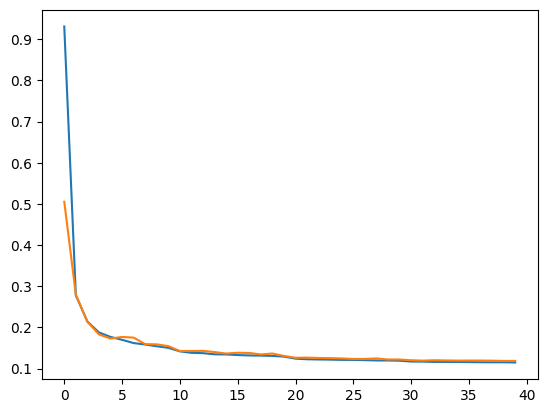

In [ ]:
plt.plot(list_train_loss_M)
plt.plot(list_val_loss_M)

[np.int64(178)]
CPU times: user 211 ms, sys: 3.99 ms, total: 215 ms
Wall time: 216 ms


np.int64(33)

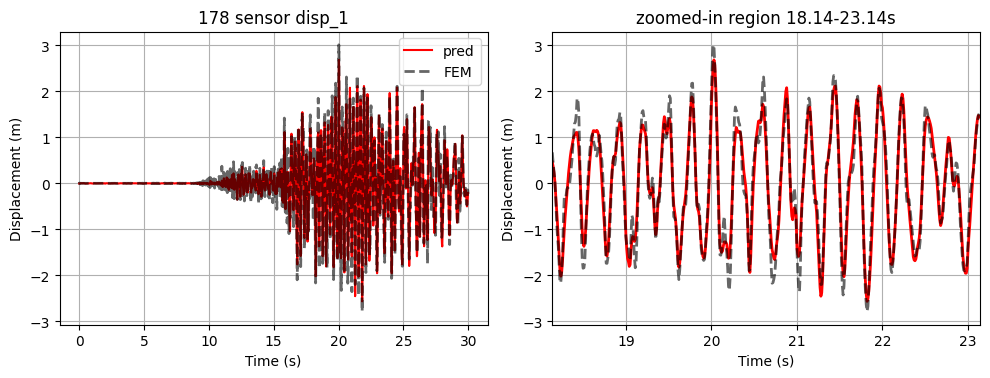

In [ ]:
%%time
plt.figure(figsize=(10,14))

list_ip = [idx_val[np.random.choice(len(idx_val))]]
print(list_ip)
y_predict_all = inference_5tor(model_tor, aggregation, df_new, list_ip)

list_color = ['r', 'orange', 'm', 'g']
for i,ip in enumerate(list_ip):
  plt.subplot(421+i*2)
  # i_s = np.random.randint(N_output)
  i_s = 0
  length = len(df_new[list_output_time[i_s]][ip])
  t= np.arange(0,len(df_new[list_output_time[i_s]][ip][:]))*0.01
  plt.plot(t, y_predict_all[i, L_all:L_all+L_ground,i_s][:],list_color[i], linewidth=1.5)
  plt.plot(t, df_new[list_output_time[i_s]][ip][:],'--k', alpha = 0.6, linewidth=2)
  plt.legend(['pred', 'FEM'], loc=0)
  plt.title(f'{ip} sensor {list_output_time[i_s]}', fontsize=12)
  plt.xlabel('Time (s)')
  plt.ylabel('Displacement (m)')
  # plt.ylim(-0.04, 0.04)
  # plt.xlim(0,28)
  plt.grid(True)


  plt.subplot(422+i*2)
  length = len(df_new[list_output_time[i_s]][ip])
  t= np.arange(0,len(df_new[list_output_time[i_s]][ip][:]))*0.01
  # t1, t2 = 800, 1200
  t1 = np.random.randint(0,2200)
  t2 = t1+500
  yy = y_predict_all[i, L_all:L_all+length,i_s][:]
  plt.plot(t[t1:t2], yy[t1:t2],list_color[i], linewidth=2)
  yy = df_new[list_output_time[i_s]][ip][:]
  plt.plot(t[t1:t2], yy[t1:t2],'--k', alpha = 0.6, linewidth=2)
  plt.title(f'zoomed-in region {t1/100}-{t2/100}s', fontsize=12)
  plt.xlabel('Time (s)')
  plt.ylabel('Displacement (m)')
  plt.xlim(t1*0.01, t2*0.01)
  plt.grid(True)
  # plt.ylim(-0.042, 0.042)

plt.tight_layout();
# plt.savefig(f'{ex_name}_1.png',dpi=400)
df['idEQ'][ip]

In [ ]:
%%time
list_ip = list(range(len(df_new)))
y_predict_all = inference_5tor(model_tor, aggregation, df_new, list_ip)


CPU times: user 2.78 s, sys: 663 ms, total: 3.44 s
Wall time: 3.46 s


In [ ]:
with open('PINNex2_xlstm_good.p','wb') as f:
  pickle.dump(y_predict_all, f)
  pickle.dump(y_ref, f)
  pickle.dump(list_train_loss_M, f)
  pickle.dump(list_val_loss_M, f)
  pickle.dump(model_tor, f)
  pickle.dump(aggregation, f)


In [ ]:
y_ref = df_new[list_output_time].values
y_ref = np.array([np.stack(y_ref[i], axis=1) for i in range(len(y_ref))])

In [ ]:
ymax_ref = np.max(np.abs(y_ref), axis=(1))
ymax_pred = np.max(np.abs(y_predict_all), axis=(1))

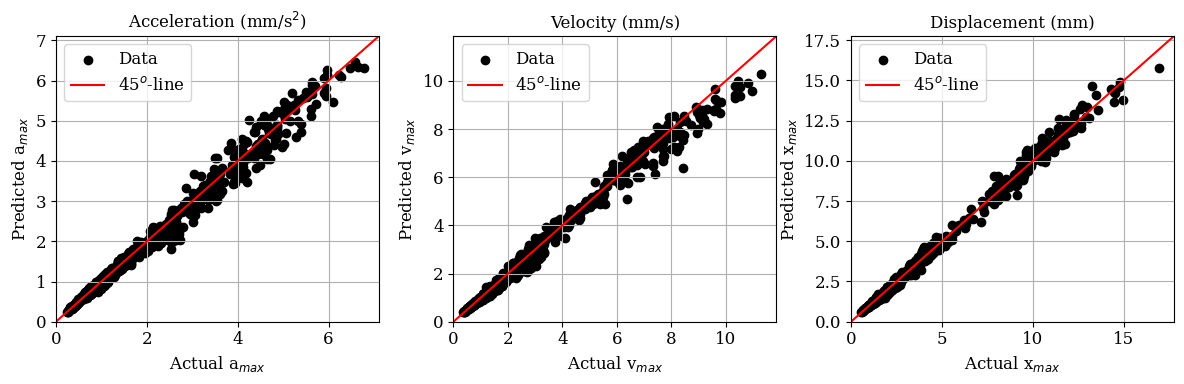

In [ ]:
plt.figure(figsize=(12,4))
list_symbol = ['a','v','x']
list_signal = ['Acceleration', 'Velocity', 'Displacement']
list_unit = ['mm/s$^2$','mm/s','mm']

for i in range(3):
  axs = plt.subplot(131+i)
  vmax = np.max(ymax_ref[:,i])*1.05
  plt.scatter(ymax_ref[:,i], ymax_pred[:,i], color='black')
  plt.plot([0,vmax],[0,vmax],'-r')
  plt.ylabel(f'Predicted {list_symbol[i]}'+'$_{max}$')
  plt.xlabel(f'Actual {list_symbol[i]}'+'$_{max}$')
  plt.title(f'{list_signal[i]} ({list_unit[i]})', fontsize=12)
  plt.grid(True)
  plt.legend(['Data','45$^o$-line'])
  vlim = vmax
  plt.xlim([0,vlim])
  plt.ylim([0,vlim])
  # plt.yticks([0,np.round(vlim//5, decimals=-1), np.round(vlim*2//5, decimals=-1), np.round(vlim*3//5, decimals=-1), np.round(vlim*4//5, decimals=-1), np.round(vlim)])
  # plt.xticks([0,np.round(vlim//5, decimals=-1), np.round(vlim*2//5, decimals=-1), np.round(vlim*3//5, decimals=-1), np.round(vlim*4//5, decimals=-1), np.round(vlim)])
plt.tight_layout()
# plt.savefig('wall_45.png', dpi=350)



In [ ]:
from matplotlib import rcParams, rc
rcParams['font.family'] = 'serif'
rcParams['font.sans-serif'] = ['Time New Roman']
fsize = 12
rcParams.update({'font.size': fsize})

In [ ]:
def plot_results2(axs, y_ref, y_predict, fsize=10, ia=0, ii = 100):
  list_signal = ['Acceleration', 'Velocity', 'Displacement']
  list_color = ['r', 'orange', 'm', 'g']
  list_unit = ['mm/s$^2$','mm/s','mm']
  t= np.arange(0,3000)*0.01
  axs[ia, 0].plot(t, y_predict,list_color[ia], linewidth=2)
  axs[ia, 0].plot(t, y_ref,'--k', alpha = 0.6, linewidth=2)
  axs[ia, 0].set_xlim(0,30)
  axs[ia, 0].grid(True)

  t= np.arange(0,3000)*0.01
  ttt = np.argmax(y_ref)
  # ttt = 1100
  t1 = ttt-150
  t2 = t1+300
  axs[ia, 1].plot(t[t1:t2], y_predict[t1:t2],list_color[ia], linewidth=2)
  axs[ia, 1].plot(t[t1:t2], y_ref[t1:t2],'--k', alpha = 0.6, linewidth=2)
  axs[ia, 1].legend(['pred', 'ref'], loc=1)

  # Annotate peak with arrow and error metric using ax.annotate
  peak_time = t[ttt]
  peak_pred = y_ref[ttt]
  abs_error = int(np.abs(y_ref[ttt]  - y_predict[ttt])/y_ref[ttt]*100)
  axs[ia, 1].annotate(
      f'peak error: {abs_error:.0f}%',
      xy=(peak_time, peak_pred),
      xytext=(peak_time-1.5, peak_pred*0.8),
      arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
      bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white'),
      color='red'
  )

  axs[ia, 0].set_title(f'Example 1 id_{ii} {list_signal[ia]}', fontsize=fsize)
  axs[ia, 1].set_title(f'Example 1 zoomed-in {t1/100}-{t2/100}s', fontsize=fsize)
  if ia==2:
    axs[ia, 0].set_xlabel('Time (s)')
    axs[ia, 1].set_xlabel('Time (s)')

  axs[ia, 0].set_ylabel(f'{list_signal[ia]} ({list_unit[ia]})')



In [ ]:
y_ref.shape

(1000, 3000, 9)

386
CPU times: user 349 ms, sys: 5.98 ms, total: 355 ms
Wall time: 410 ms


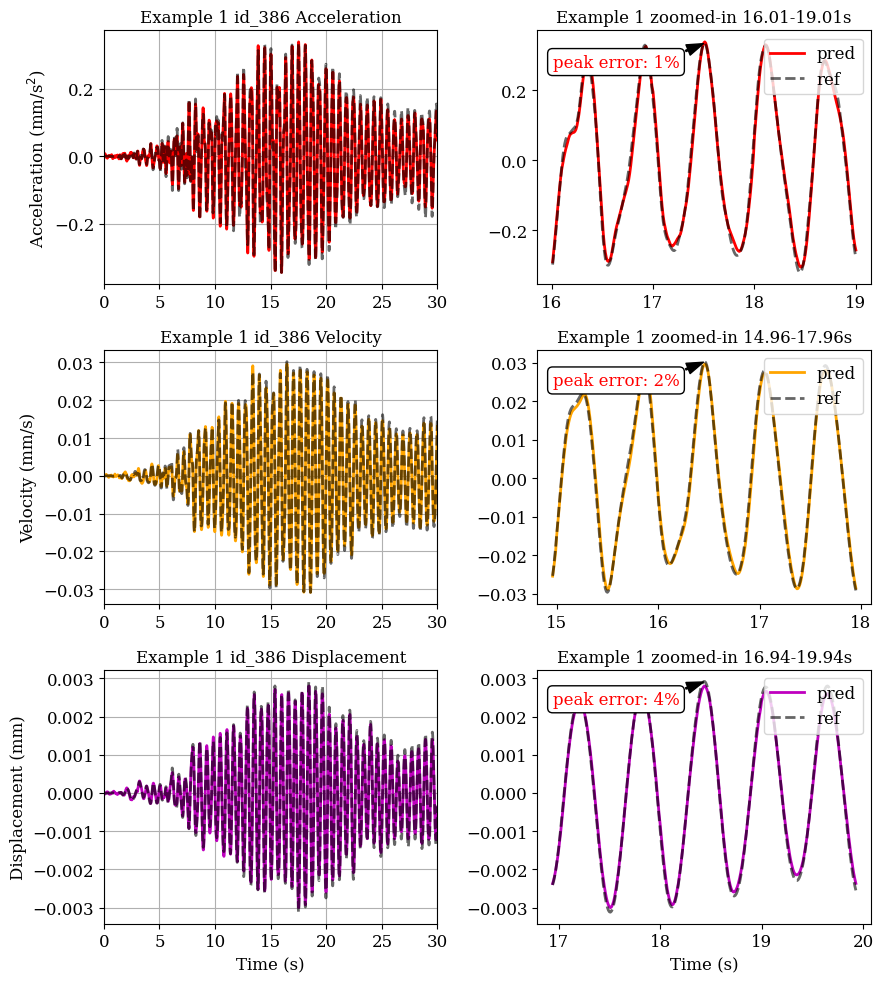

In [ ]:
%%time
# ii = np.random.randint(0,len(y_ref), 1)[0]
ii = 386
print(ii)
fig, axs = plt.subplots(3,2, figsize=(9, 10))
for ia in range(3):
  y_rf = y_ref[ii,:,ia*3]
  y_predict = y_predict_all[ii,150:,ia*3]
  plot_results2(axs, y_rf, y_predict, fsize, ia, ii)

plt.tight_layout();
# plt.savefig('sparse1.png', dpi=350)

In [ ]:
with open('PINNex2_xlstm_good.p','rb') as f:
  y_predict_all = pickle.load(f)
  y_ref = pickle.load(f)


In [ ]:
Nm = 3
identity_matrix = np.eye(3)
list_mm = df[['m1','m2','m3']].values
list_cc = df[['c1','c2','c3']].values
list_kk = df[['k1','k2','k3']].values

M_ = np.einsum('bi,ij->bij', list_mm, identity_matrix)
C_ = np.einsum('bi,ij->bij', list_cc, identity_matrix)
K_ = np.einsum('bi,ij->bij', list_kk, identity_matrix)
for i in range(Nm-1):
  K_[:,i,i] += list_kk[:,i+1]
  K_[:,i,i+1] = -list_kk[:,i+1]
  K_[:,i+1,i] = -list_kk[:,i+1]

for i in range(Nm-1):
  C_[:,i,i] += list_cc[:,i+1]
  C_[:,i,i+1] = -list_cc[:,i+1]
  C_[:,i+1,i] = -list_cc[:,i+1]

x_tt = y_ref
mck_ref     = np.einsum('bij,bLj->bLi', M_, x_tt[:,:,:3]) + np.einsum('bij,bLj->bLi', C_, x_tt[:,:,3:6])+ np.einsum('bij,bLj->bLi', K_, x_tt[:,:,6:9])
x_tt = y_predict_all[:,150:,:]
mck_predict    = np.einsum('bij,bLj->bLi', M_, x_tt[:,:,:3]) + np.einsum('bij,bLj->bLi', C_, x_tt[:,:,3:6])+ np.einsum('bij,bLj->bLi', K_, x_tt[:,:,6:9])

In [ ]:
mck_residual = np.zeros_like(mck_ref, dtype=float)
non_zero_mask = np.where(mck_ref > 1E-6)
mck_residual[non_zero_mask] = ((mck_ref[non_zero_mask] - mck_predict[non_zero_mask]) / np.maximum(np.abs(mck_predict[non_zero_mask]),np.abs(mck_ref[non_zero_mask])) * 100)
mck_residual = np.mean(mck_residual, axis=(1,2))

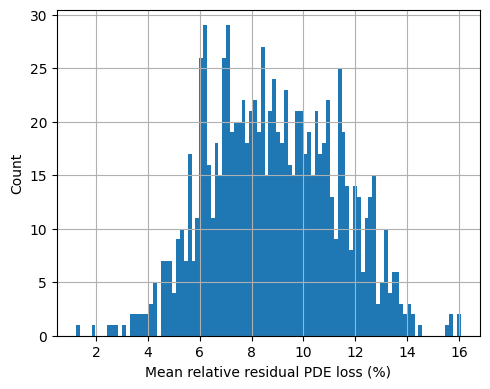

In [ ]:
plt.figure(figsize=(5,4))
plt.hist(mck_residual,bins=100);
plt.ylabel('Count')
plt.xlabel(f'Mean relative residual PDE loss (%)')
plt.grid(True)
plt.tight_layout()

